In [1]:
!mkdir data
!wget https://github.com/mannefedov/compling_nlp_hse_course/raw/master/data/lenta.txt.zip -P data
!unzip -o data/lenta.txt.zip -d data/

--2026-09-26 15:28:22--  https://github.com/mannefedov/compling_nlp_hse_course/raw/master/data/lenta.txt.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mannefedov/compling_nlp_hse_course/master/data/lenta.txt.zip [following]
--2026-09-26 15:28:23--  https://raw.githubusercontent.com/mannefedov/compling_nlp_hse_course/master/data/lenta.txt.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5723675 (5.5M) [application/zip]
Saving to: ‘data/lenta.txt.zip’

lenta.txt.zip       100%[===================>]   5.46M  --.-KB/s    in 0.08s   

2026-09-26 15:28:23 (65.5 MB/s) - ‘data/lenta.txt.zip’ sa

In [13]:
corpus = open('data/lenta.txt').read()

## Задание 1. (1 балл)

Посчитайте частоты для 5-грамм в корпусе lenta.txt. двумя способами:  
1) Текст токенизируется в один сплошной список токенов и нграммы считаются по всем токенам без учета границ предложений
2) Текст разбивается на предложения, а каждое предложение на токены; нграммы собираются с учетом границ предложений
    
Найдите различия между топ 100 нграммов для первого и второго способов

In [2]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk import sent_tokenize
from nltk.tokenize import word_tokenize
import re
from collections import Counter

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [6]:
# Способ 1
russian_stopwords = stopwords.words('russian')
sentences = sent_tokenize(corpus, language='russian')
tokenized_sentences = [word_tokenize(sentence) for sentence in sentences]
tokenized_sentences = [[token.lower() for token in sentence if not re.match(r'\W+', token) and token.lower() not in russian_stopwords]
                       for sentence in tokenized_sentences]

def ngrammer(tokens, n=5):
  ngrams = []
  for i in range(len(tokens)-n+1):
    ngrams.append(' '.join(tokens[i:i+n]))
  return ngrams

flat_tokens = [token for sentence in tokenized_sentences for token in sentence]

fivegram_counts = Counter()
fivegram_counts.update(ngrammer(flat_tokens, 5))

fivegram_counts.most_common(10)


[('объединенной группировки войск северном кавказе', 83),
 ('сообщает риа новости ссылкой пресс-службу', 57),
 ('обязанности президента россии владимир путин', 47),
 ('группировки федеральных сил северном кавказе', 37),
 ('помощник президента россии сергей ястржембский', 35),
 ('делам печати телерадиовещания средств массовых', 31),
 ('объединенной группировки федеральных сил северном', 31),
 ('печати телерадиовещания средств массовых коммуникаций', 30),
 ('штабе объединенной группировки федеральных сил', 25),
 ('министр иностранных дел россии игорь', 24)]

In [7]:
# Способ 2

fivegram_counts_2 = Counter()
for sentence in tokenized_sentences:
    fivegram_counts_2.update(ngrammer(sentence, 5))

fivegram_counts_2.most_common(10)

[('объединенной группировки войск северном кавказе', 83),
 ('сообщает риа новости ссылкой пресс-службу', 57),
 ('обязанности президента россии владимир путин', 47),
 ('группировки федеральных сил северном кавказе', 37),
 ('помощник президента россии сергей ястржембский', 35),
 ('делам печати телерадиовещания средств массовых', 31),
 ('объединенной группировки федеральных сил северном', 31),
 ('печати телерадиовещания средств массовых коммуникаций', 30),
 ('штабе объединенной группировки федеральных сил', 25),
 ('министр иностранных дел россии игорь', 24)]

In [8]:
top1 = set(dict(fivegram_counts.most_common(100)))
top2 = set(dict(fivegram_counts_2.most_common(100)))

diff1 = top1 - top2
diff2 = top2 - top1

print("Различий в топ-100:", len(diff1))
print("Уникальные для способа 1:", list(diff1))
print("Уникальные для способа 2:", list(diff2))

Различий в топ-100: 1
Уникальные для способа 1: ['президента россии сергей ястржембский передает']
Уникальные для способа 2: ['представитель правительства россии чечне николай']


## Задание 2. (1 балл)

Найдите какую-то инетересную (по вашему мнению) закономерность на https://books.google.com/ngrams/ для русского языка (с 1990 по 2022)

Вставьте сюда скриншот

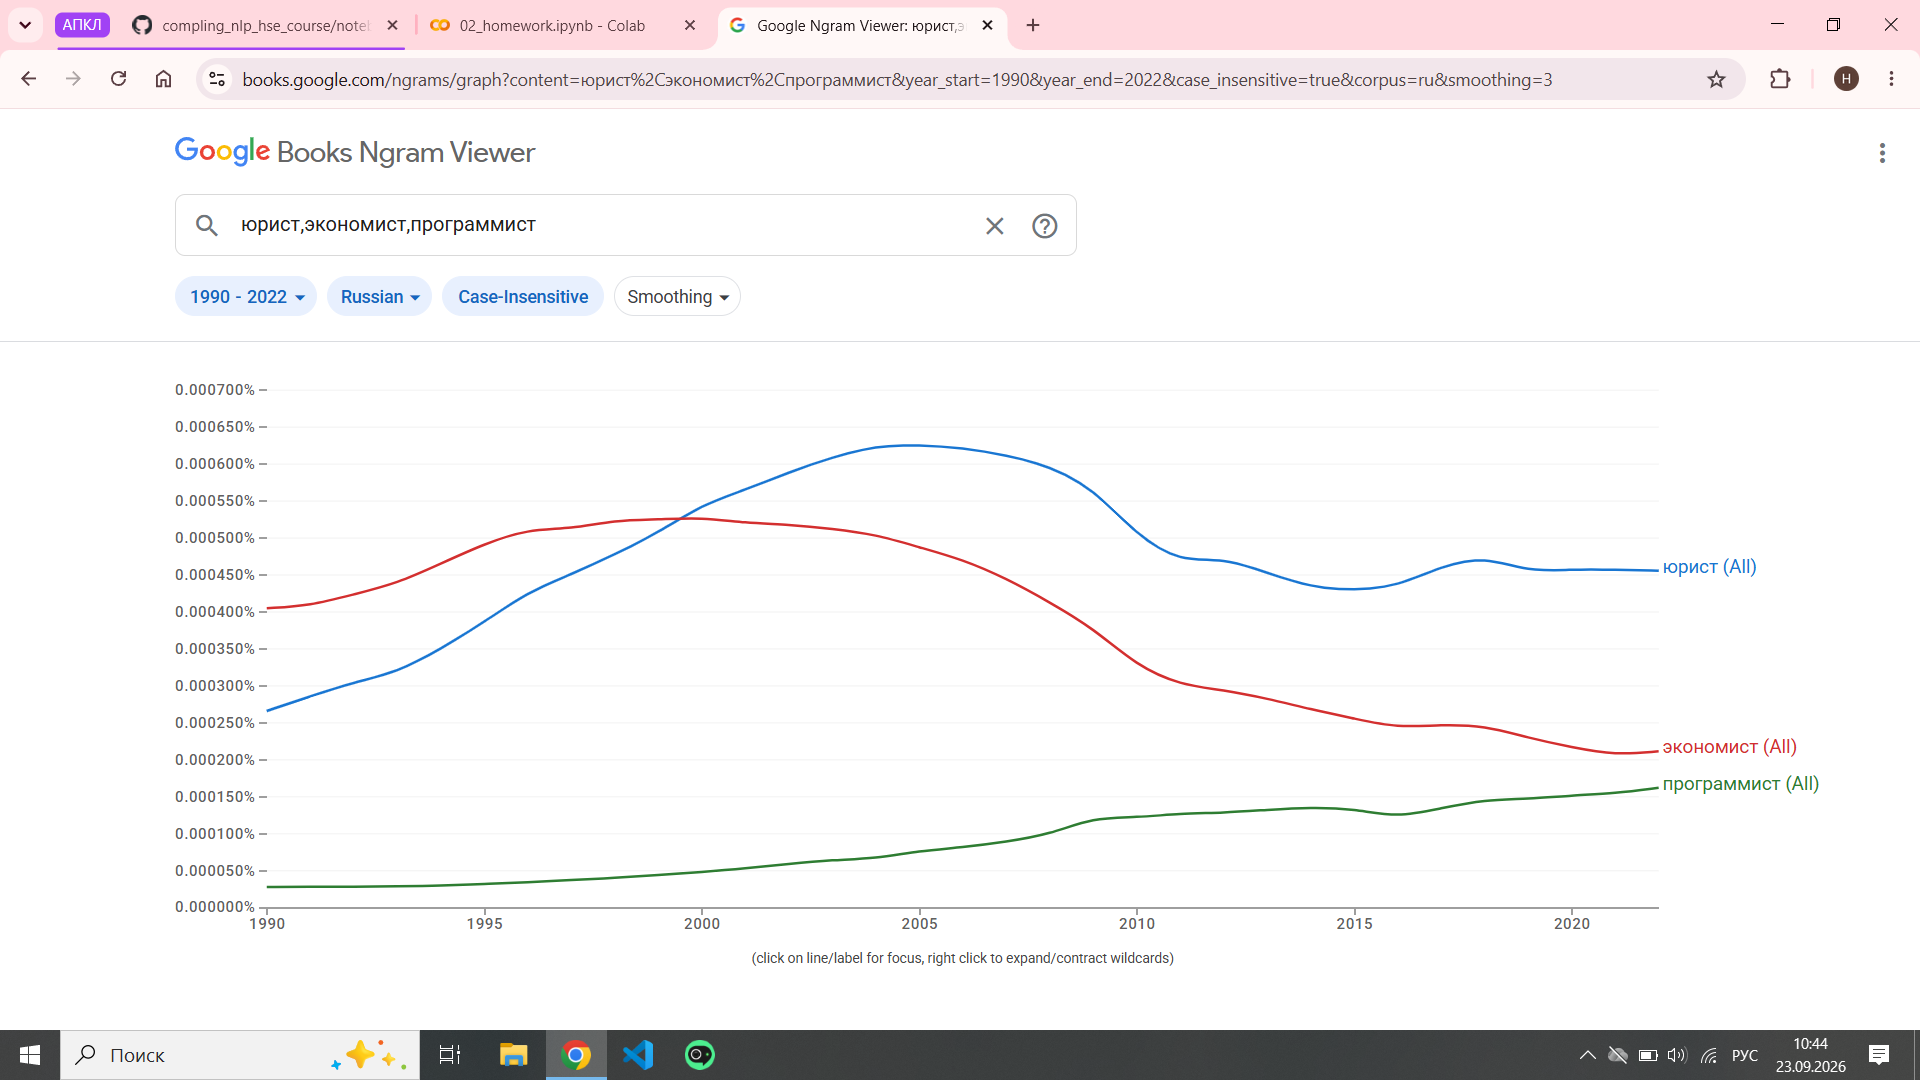

## Заданиe 3 (1 балл)

В семинаре мы использовали Dice coefficient (`score = 2 * bigram_count/((word_count_a+word_count_b))`) для нахождения коллокаций.
Но самая известная метрика для этого другая - [PMI](https://en.wikipedia.org/wiki/Pointwise_mutual_information). Имплементируйте скоринг с помощью этой метрики и сравните результаты с Dice на топ 30 биграмах.
Используйте логарифмы для работы с вероятностями.

In [9]:
def ngrammer(tokens, n=2):
    return [' '.join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

unigrams = Counter()
bigrams = Counter()
for sent in tokenized_sentences:
    unigrams.update(sent)
    bigrams.update(ngrammer(sent, 2))

N = sum(unigrams.values())

In [10]:
import math

def scorer_pmi(*args):
  word_count_a, word_count_b, bigram_count, N, min_count = args
  try:
    score = math.log2((bigram_count * N) / (word_count_a * word_count_b))
  except ZeroDivisionError:
    return 0
  return score

bigram2score_pmi = Counter()
for bigram in bigrams:
  if bigrams[bigram] < 10:
    continue
  word_a, word_b = bigram.split()
  score = scorer_pmi(unigrams[word_a], unigrams[word_b], bigrams[bigram], N, 10)
  if score > -100000:
      bigram2score_pmi[bigram] = score

In [11]:
def scorer_dice(*args):
    word_count_a, word_count_b, bigram_count, N, min_count = args
    try:
        score = (2 * bigram_count) / (word_count_a + word_count_b)
    except ZeroDivisionError:
        return 0
    return score

bigram2score_dice = Counter()
for bigram in bigrams:
  if bigrams[bigram] < 10:
    continue
  word_a, word_b = bigram.split()
  score = scorer_dice(unigrams[word_a], unigrams[word_b], bigrams[bigram], N, 10)
  if score > -100000:
      bigram2score_dice[bigram] = score

In [12]:
print("PMI:")
for bigram, score in bigram2score_pmi.most_common(30):
    print(f"  {bigram}: {score:.4f}")

print("\nDice:")
for bigram, score in bigram2score_dice.most_common(30):
    print(f"  {bigram}: {score:.4f}")

PMI:
  mein kampf: 16.7829
  мысе канаверал: 16.6454
  стихийных бедствий: 16.6454
  брюшным тифом: 16.6454
  интенсивной терапии: 16.5199
  at t: 16.5199
  пит сампрас: 16.5199
  ясиром арафатом: 16.4044
  burger king: 16.4044
  ломоносовский фарфоровый: 16.3824
  полевыми командирами: 16.2975
  bp amoco: 16.2569
  ясир арафат: 16.1980
  assigned names: 16.1980
  зенон н.с.п: 16.1980
  алкогольного опьянения: 16.1414
  часовым механизмом: 16.1049
  прожиточного минимума: 16.0605
  drudge report: 16.0565
  corriere della: 16.0174
  della sera: 16.0174
  climate orbiter: 16.0174
  строуб тэлботт: 16.0174
  брюшного тифа: 16.0174
  северному кавказу: 15.9979
  mci worldcom: 15.9793
  lockheed martin: 15.9496
  philip morris: 15.9349
  элла памфилова: 15.9349
  линдсей дэвенпорт: 15.8760

Dice:
  della sera: 1.0000
  philip morris: 1.0000
  at t: 1.0000
  стихийных бедствий: 1.0000
  mein kampf: 1.0000
  брюшного тифа: 1.0000
  риа новости: 0.9858
  dow jones: 0.9825
  wall street: 0.9811

# Задание 4 (2 балл)

Шаг 1: Измените функцию merge_round так чтобы она использовала скоринг, который вы сделаете в задании выше.
Шаг 2: Подберите параметры (min_count, n_merges, n_rounds) так чтобы получались адекватные результаты
Шаг 3: Сохраните промежуточные словари мержей и напишите функцию, которая их последовательно применяет, чтобы иметь возможности воспроизвести трансформацию на любой новом тексте

Подберите несколько предложений, на которых функция трансформации будет склеивать хотя бы несколько слов вместе

In [50]:
def merge_round(sub_corpus, min_count=5, n_merges=300):
    unigrams = Counter()
    bigrams = Counter()
    for sent in sub_corpus:
        unigrams.update(sent)
        for i in range(len(sent) - 1):
            bigrams[(sent[i], sent[i+1])] += 1

    N = sum(unigrams.values())

    bigram2score = {}
    for bigram, count in bigrams.items():
        if count < min_count:
            continue
        word_a, word_b = bigram
        score = scorer_pmi(unigrams[word_a], unigrams[word_b], count, N, min_count)
        bigram2score[bigram] = score

    top_merges = sorted(bigram2score.items(), key=lambda x: x[1], reverse=True)[:n_merges]

    merges_dict = {bigram: f"{bigram[0]}_{bigram[1]}" for bigram, _ in top_merges}

    new_sub_corpus = []
    for sent in sub_corpus:
        new_sent = []
        i = 0
        while i < len(sent):
            if i < len(sent) - 1 and (sent[i], sent[i+1]) in merges_dict:
                new_sent.append(merges_dict[(sent[i], sent[i+1])])
                i += 2
            else:
                new_sent.append(sent[i])
                i += 1
        new_sub_corpus.append(new_sent)

    return new_sub_corpus, merges_dict

In [51]:
sub_corpus = [list(sent) for sent in tokenized_sentences]

saved_merged = []
for round_i in range(1, 10):
    sub_corpus, merges = merge_round(sub_corpus)
    saved_merged.append(merges)

def tokenize(text):
    tokens = word_tokenize(text)
    return [token.lower() for token in tokens if not re.match(r'\W+', token) and token.lower() not in russian_stopwords]

def apply_merges(text, merges=saved_merged):
    merged_text = list(text)
    for merges_dict in merges:
        new_text = []
        i = 0
        while i < len(merged_text):
            if i < len(merged_text) - 1 and (merged_text[i], merged_text[i+1]) in merges_dict:
                new_text.append(f"{merged_text[i]}_{merged_text[i+1]}")
                i += 2
            else:
                new_text.append(merged_text[i])
                i += 1
        merged_text = new_text
    return merged_text

new_text_1 = tokenize("в компаниях силиконовой долины системные администраторы часто используют операционную систему red hat и язык visual basic")
print(apply_merges(new_text_1))

new_text_2 = tokenize("в нагорном карабахе тренер по фигурному катанию попал в больницу с сердечным приступом после того как под его машиной была найдена тротиловая шашка")
print(apply_merges(new_text_2))

new_text_3 = tokenize("никита михалков обсудил проблемы по сельскому хозяйству на встрече в саудовской аравии")
print(apply_merges(new_text_3))

['компаниях', 'силиконовой_долины', 'системные_администраторы', 'часто', 'используют', 'операционную_систему', 'red_hat', 'язык', 'visual_basic']
['нагорном_карабахе', 'тренер', 'фигурному_катанию', 'попал', 'больницу', 'сердечным_приступом', 'машиной', 'найдена', 'тротиловая_шашка']
['никита_михалков', 'обсудил', 'проблемы', 'сельскому_хозяйству', 'встрече', 'саудовской_аравии']


# Задание 5 (3 балла)

Напишите краткое эссе (30 - 50 предложений) в свободной форме по одной из этих статей:
1) https://news.microsoft.com/source/2026/09/09/aft-uft-and-microsoft-announce-national-ai-safety-privacy-standard-for-schools-to-protect-students-families-and-educators/ и сам целый документ https://www.aft.org/sites/default/files/media/documents/2026/NAfAI-School_AI_Privacy_Standards.pdf
2) https://bayareacurrent.com/theres-a-lot-of-cleaning-up-poop-a-depot-worker-on-the-human-labor-behind-waymos-autonomous-vehicles/

Эту часть достаточно сложно оценивать формально, но я ожидаю увидеть ваши содержательные рассуждения о написанном в статье.   
Если после прочтения вам ничего не приходит в голову, то вы можете начать со следующих вопросов: Считаете ли вы эту информацию важной/интересной/страшной/скучной/и тп? Что показалось вам наиболее важным? Почему? Считаете ли вы эту статью объективной? Какие пробелы вы видите? По вашему мнению будет ли продолжение у этих историй? В каком направлении они будут развиваться? Считаете ли вы age restriction необходимым для AI моделей? (для первой статьи) Как можно предотвращать/бороться с подобным антисоциальным поведением в автономных автомобилях? (для второй) ...
Но это не полный и не обязательный список! Вы можете писать о всем, что вы посчитаете нужным.

Чего точно следует избегать:
1) Не пишите саммари! Ваше эссе должно выражать ваши собственные мысли и добавлять что-то к тексту, а не заменять его.
2) Не гонитесь за полнотой! Можно и нужно опускать детали. Вы даже можете даже сфокусироваться только на каком-то одном аспекте статьи и порассуждать о нем поглубже.
3) Не отвлекайтесь на форматирование! Не используйте нумерованные списки, булет пойнты, ссылки и т.п. Напишите все как один связанный plain текст (можете разбить все на параграфы, но не более того)
4) Не объясняйте термины и понятия, не давайте определений! Считайте, что читатель знает столько же, сколько вы или же что он может погуглить.
5) Не уходите от темы! Реагируйте только на сам текст, а не на общий контекст (схожие события и работы, реакция в сотсетях и т.п). Не сравнивайте с другими статьями от того же Антропика или OpenAI.
6) Не бойтесь выражать мнение! Но либо обосновывайте его, либо описиваете свои ощущения в деталях.
7) Будьте осторожными с bias. Не списывайте все на капитализм, AI buble, AI doomerism, AI accerationalism и тому подобные слишком общие и абстрактные вещи. Не выражайте ваше личное отношение к авторам (антропику), только к содержанию статьи!



В век высоких технологий мы отовсюду слышим о будущем, в котором искусственный интеллект освободит человека от рутины, а беспилотные такси доставят, куда требуется, без лишних разговоров. Но чем ближе эта перспектива, тем отчётливее видно, что обещанная «автономность» плохо сочетается с реальностью. Стоит роботакси столкнуться с нестандартной ситуацией на дороге, он замирает и блокирует городское движение. Так может ли автомобиль быть автономным в условиях, где действует множество участников? Ведь движение в городе – это совместная задача. Она требует не только распознавания препятствий, но и согласования действий. Если два автомобиля не обмениваются намерениями, они могут бесконечно уступать друг другу. Компания выбирает стратегию невмешательства: пусть машина сама учится. Но обучение происходит не в изолированной среде, а на улицах. Расходы на ошибки несут жители, которые из-за подобных ситуаций могут сами лишиться работы, опоздав на нее.

Отдельной темой является то, что за этой иллюзией абсолютной автономии скрывается тяжелый, монотонный и низкооплачиваемый человеческий труд. Чтобы конечный пользователь поверил в магию искусственного интеллекта, индустрия должна сделать невидимыми тех, кто эту магию обеспечивает. Клиент, сидя в салоне, даже и не подозревает, что в момент «ступора» где-то за тысячи километров от него, на Филиппинах, оператор колл-центра буквально «подсказывает» машине, куда ехать. Он уверен, что автомобиль принимает решение сам, однако делает это все дешевая рабочая сила из стран третьего мира.

Показательно, что чем сложнее техника, тем больше ручной работы требуется для поддержания её работоспособности. Программный сбой на парковке решается не перезагрузкой системы, а физическим толчком: живой человек должен подойти и сдвинуть машину на несколько сантиметров. Протереть оптику от дождя или насекомых, перезапустить зависший модуль – эти действия не требуют квалификации, но без них «автономность» рассыпается. Именно поэтому такой труд выносится за пределы бренда. Субподряд не просто экономит деньги, он позволяет сохранять образ работодателя из Кремниевой долины, где нет места травмам и текучке. Грязная работа остаётся, но её как бы не существует. Показательно и то, как подрядчик управляет людьми: вместо нормальной организации труда он поощряет доносы и слежку. Это не просто плохой менеджмент, а способ переложить ответственность на самих работников.

Наконец, за этой иллюзией автоматизации прячется еще одна неудобная истина: отсутствие водителя в салоне роботакси не делает пассажиров более цивилизованными. Напротив, оно снимает социальные табу. Часто присутствие человека останавливает людей от тех или иных действий, однако в роботакси можно все. И что еще хуже, компания держится за таких клиентов, ведь они приносят доход. Однако очистка салонов от рвоты, мусора и даже конечных продуктов жизнедеятельности организма – это тяжелый, неприятный и опасный для здоровья труд, который выполняют люди за минимальную ставку, пока компания Waymo продолжает говорить о «чистом и безопасном будущем». Свиные головы, упомянутые в интервью, – яркий пример того, с каким хаосом реального мира сталкивается мир технологий.

Таким образом, проблема Waymo не в том, что машины недостаточно умны. Проблема в том, что автономия понимается как независимость от других, а не как способность координироваться с ними. В городе свобода одного участника заканчивается там, где начинается необходимость учитывать других. Без механизмов согласования и прозрачной ответственности беспилотный транспорт не может стать шагом в будущее.

Эта же логика видна и в том, как устроен труд вокруг роботакси. Автоматизация в 21 веке изменила свой вектор: она больше не заменяет человека машиной полностью, она дробит человеческий труд на тысячи мелких, невидимых глазу задач, лишая рабочих признания. Настоящий прогресс начнётся не тогда, когда машины научатся ездить без водителей, а тогда, когда общество признает и начнёт уважать труд тех, кто сегодня вынужден оставаться невидимыми.
